# *Pós-graduação em Ciêcia de Dados e Inteligência Artificial*
### *Trabalho Final - Machine Learning I*

**Disciplina:** Machine Learning

**Professor:** André Juan Costa Vieira

**Turma:** 

**Nomes dos Integrantes:** 

1- Paulo Vinicius Mota

2- Julia Mendonça Ferreira

3-

4- 

## Qualidade de vinhos. 

Você foi contratado como cientista de dados pela famosa vinícola **"Vini Tradizionali di Manduria"** para analisar todos os aspectos dos vinhos produzidos. Diversas questões foram levantadas, como: Compreender os padrões das características que proporcionam boas safras e a qualidade de novos vinhos produzidos, antes que a comunidade mundial **"Vins Spectaculaires"** os deguste, apontar quais são os novos **"blends"** que podem ter continuidade no desenvolvimento, dentre várias outras atividades que visam as boas tomadas de decisões, sempre com o intuito de servir os melhores rótulos, aumentando os lucros e diminuindo os gastos.        

A equipe de enólogos faz estudos frequentes para verificar as características de cada vinho, colocando-os em planilhas. Para melhor compreensão dos dados, descreveram o que significado de cada propriedade.   


##### Descrição 

**0. Color:** Se o vinho é tinto vermelho ou branco

**1. Fixed Acidity:** Qtd.de Ácido não volátil, aquele que não evapora fácil

**2. Volatile Acidity:** Teor de ácido acético que leva a um sabor desagradável de vinagre

**3. Citric Acid:** Um tipo de ácido que age como conservante para aumentar o nível de acidez em pequena quantidade para adicionar aroma e sabor

**4. Residual Sugar:** Qtd. de açúcar restante depois da fermentação, mais de 45g/litro é doce

**5. Chlorides:** Qtd. de sal

**6. Free Sulfur Dioxide:** Componente que impede crescimento microbiano e a oxidação do vinho

**7. Total Sulfur Dioxide:** Qtd. de SO2 (dióxido de enxofre)

**8. Density:** Densidade do vinho,

**9. pH:** Nível de acidez ou potencial hidrogeniônico

**10. Sulphates:** Um adicional que contribui para níveis de SO2 e é 
antimicróbico e antioxidante 

**11. Alcohol:** Qtd. de álcool

**12. Qualidade:** Notas de 3 a 9

# Questões

### Importe todas as bibliotecas necessárias na célula abaixo
##### Organize-as de forma crescente em relação ao tamanho da frase

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

### Tratamento dos Dados


Sir. Pounce, enólogo de longa data, especializado em vinhos italianos, descobriu que estão faltando alguns valores nas planilhas, e que outros dados foram alterados pelo ex-funcionário Smeagle, dispensado por degustar vinhos 'preciosos'.   

**Utilize o dataset 'wines_preprocessing.csv' para fazer as questões abaixo.**

1- Busque os valores faltantes no dataset e trate-os.

2- Busque valores incongruentes no dataset, imprima e os trate. 

3- Valide seus tratamentos com o dataset **'wines.csv'**, demonstrando se foi possível manter as distribuições de forma adequada.

In [2]:
df_wines_preprocessing = pd.read_csv('../data/wines_pre_processing.csv')
df_valores_faltantes = df_wines_preprocessing.isnull().sum() #1 - buscando valores faltantes 

#df_wines_preprocessing.dtypes

colunas_numericas = df_wines_preprocessing.columns.drop('color') # Pego as colunas numericas e dropo a coluna categorica color 

incongruentes_por_coluna = {}  # dicionário pra guardar os incongruentes de cada coluna para printar dps

for col in colunas_numericas: #2 loop que percore a coluna buscando valores incongruentes, texto no lugar de numero. 
    coluna_original = df_wines_preprocessing[col]
    coluna_convertida = pd.to_numeric(coluna_original, errors='coerce')
    valores_incongruentes = coluna_convertida.isna() & coluna_original.notna()
    incongruentes_por_coluna[col] = coluna_original[valores_incongruentes]  # <- novo: salva o resultado dessa coluna
    #print("Valor Incongruente : ", coluna_original[valores_incongruentes])
    df_wines_preprocessing[col] = coluna_convertida # troca a coluna  pela versão convertida

#df_wines_preprocessing.dtypes
    
df_wines_preprocessing['color'].unique() # pegando os valores de cores validas 
cores_validas = ['white','red'] # Os valores de cores realmente validas foram white e red 
cores_invalidas = ~ df_wines_preprocessing['color'].isin(cores_validas) & df_wines_preprocessing['color'].notna() # atribuo true nas posições onde o valor da color não e um valor válido tbm não é nulo
colunas_continuas = colunas_numericas.drop(['quality', 'alcohol']) #recebe as colunas numericas e dropa quality e alcohol fica pro Carlos tratar com regressão

for col in colunas_continuas:# percorre as colunas e preenche a mediana onde os valores é nulos
    df_wines_preprocessing[col] = df_wines_preprocessing[col].fillna(df_wines_preprocessing[col].median())

df_wines_preprocessing.isna().sum()  # confere quantos faltantes restam depois de tratar as colunas contínuas

cores_incongruentes_valores = df_wines_preprocessing['color'][cores_invalidas].copy()  # guarda o texto original antes de virar NaN
df_wines_preprocessing.loc[cores_invalidas, 'color'] = np.nan  # substitui os valores incongruentes de color por NaN pra poder tratá-los com fillna

df_wines_preprocessing['quality'] = df_wines_preprocessing['quality'].fillna(df_wines_preprocessing['quality'].mode()[0])  # preenche os faltantes de quality com a moda

df_wines_preprocessing['color'] = df_wines_preprocessing['color'].fillna(df_wines_preprocessing['color'].mode()[0])  # preenche os faltantes de color com a moda

df_wines_preprocessing['quality'] = df_wines_preprocessing['quality'].astype(int)  # converte quality pra inteiro 
df_wines_preprocessing.isna().sum()  # confirma que não tem nenhum valor faltante no dataset

Unnamed: 0               0
color                    0
fixed acidity            0
volatile acidity         0
citric acid              0
residual sugar           0
chlorides                0
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       0
sulphates                0
alcohol                 15
quality                  0
dtype: int64

In [3]:
print("1) VALORES FALTANTES: ")
print(df_valores_faltantes)

faltantes_finais = df_wines_preprocessing.isna().sum()
print("\nFaltantes restantes por coluna:")
print(faltantes_finais)
print("\n alcohol foi deixada de propósito com faltantes, para o Carlos tratar com regressão")
print("Faltantes fora de alcohol:", faltantes_finais.drop('alcohol').sum())

1) VALORES FALTANTES: 
Unnamed: 0              0
color                   3
fixed acidity           7
volatile acidity        2
citric acid             4
residual sugar          2
chlorides               7
free sulfur dioxide     2
total sulfur dioxide    1
density                 1
pH                      2
sulphates               6
alcohol                 4
quality                 0
dtype: int64

Faltantes restantes por coluna:
Unnamed: 0               0
color                    0
fixed acidity            0
volatile acidity         0
citric acid              0
residual sugar           0
chlorides                0
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       0
sulphates                0
alcohol                 15
quality                  0
dtype: int64

 alcohol foi deixada de propósito com faltantes, para o Carlos tratar com regressão
Faltantes fora de alcohol: 0


In [4]:
print("2) VALORES INCONGRUENTES: ")
for col, valores in incongruentes_por_coluna.items():
    if len(valores) > 0:
        print(f"\n{col}:")
        print(valores)

print(f"\nValores incongruentes em 'color':")
print(cores_incongruentes_valores)

2) VALORES INCONGRUENTES: 

fixed acidity:
607     leonidas, para te arrumar essas "confusão"
854                                            amo
1532                                      starwars
3276                                    vinho ruim
3298                                       Julieta
3374                                      deu ruim
3564                                    vinho ruim
3885    leonidas, para te arrumar essas "confusão"
5211                                      deu ruim
5832    leonidas, para te arrumar essas "confusão"
6332    leonidas, para te arrumar essas "confusão"
Name: fixed acidity, dtype: str

volatile acidity:
623     deep learning
729          starwars
1570               ml
1713         deu ruim
1737         starwars
1794            Romeu
2843         starwars
3277              amo
3946      vai dar não
5872              amo
6317    deep learning
Name: volatile acidity, dtype: str

citric acid:
447                                        Julieta
244

In [5]:
df_wines = pd.read_csv("../data/wines.csv")  # carrega o dataset de referência
print("3) VALIDAÇÃO COM WINES.CSV: ")
display(df_wines.describe())
display(df_wines_preprocessing.describe())

3) VALIDAÇÃO COM WINES.CSV: 


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6482.000000,6497.000000
mean,3248.000000,7.215122,0.339637,0.318544,5.441758,0.056032,30.524242,115.767816,0.994697,3.218472,0.531313,10.491628,5.818378
std,1875.666681,1.294640,0.164606,0.145070,4.757263,0.035024,17.728313,56.493403,0.002997,0.160655,0.148611,1.192386,0.872726
min,0.000000,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,1624.000000,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.500000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,3248.000000,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,4872.000000,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,6496.000000,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


O dono da vinícola, Sir. Donald Shelby, tem um filho cursando especialização em ciência de dados, que, ao deparar-se com o dataset, pediu a você que, ao invés de ficar tratando dados com 'essas' técnicas triviais, fizesse um algoritmo de regressão logística para encontrar os valores faltantes na coluna 'Alcohol'. O Sr. Shelby é um homem conhecido como mafioso e considera seu filho um gênio, por isso, você, com fortes receios de sofrer consequências inusitadas por ordem do Don Corleone da atualidade, acatou o "pedido".


4- Desenvolver um algoritmo de regressão logística visando preencher os dados faltantes da coluna "Alcohol". Em seguida, valide os resultados com o dataset **"wines.csv"**, apresentando todas as métricas de classificação estudadas. 

5- Você, ao ver os resultados encontrados, se adiantou e fez um modelo de regressão polinomial para dirimir a questão. Em seguida, validou os resultados com o dataset **"wines.csv"**, utilizando todas as métricas de regressão estudadas. Por fim, escreverá um e-mail explicando o motivo <u>técnico</u> que o levou a não utilizar a regressão logística neste problema, bem como qual a melhor técnica que encontrou para tratar os valores faltantes.

In [6]:
# 4) regressão logistica para preencher alcohol

# regressão logistica é modelo de classificação: a saida é a probabilidade de cada classe.
# alcohol é um numero (vai de 8 a 14.9, mais de 100 valores diferentes), então pra usar a logistica ele precisa virar categoria.
# alcohol é cortado em 3 faixas por quantil (baixo, medio, alto), cada faixa com quase a mesma quantidade de vinhos.
# o modelo prevê a faixa e o valor faltante recebe a mediana da faixa. a questão 5 mostra o que se perde nesse corte.

df_reg = df_wines_preprocessing.drop(columns=['Unnamed: 0']).copy()  # coluna de indice que veio do csv, não descreve o vinho
df_reg['color'] = (df_reg['color'] == 'red').astype(int)  # sklearn só aceita numero: red vira 1, white vira 0

linhas_sem_alcohol = df_reg['alcohol'].isna()  # 15 linhas ficaram sem alcohol depois do tratamento (4 vazias e 11 com texto)
print("linhas com alcohol faltando:", linhas_sem_alcohol.sum())

X = df_reg.drop(columns=['alcohol'])  # todas as outras colunas entram como feature, inclusive quality
X_conhecido = X[~linhas_sem_alcohol]
X_faltante = X[linhas_sem_alcohol]
y_conhecido = df_reg.loc[~linhas_sem_alcohol, 'alcohol']
alcohol_real = df_wines.loc[linhas_sem_alcohol, 'alcohol']  # gabarito das 15 linhas, vem do wines.csv carregado na questão 3

nomes_faixas = ['baixo', 'medio', 'alto']
y_faixa, limites = pd.qcut(y_conhecido, q=3, labels=nomes_faixas, retbins=True)
print("limites das faixas:", limites.round(2))
print(y_faixa.value_counts())

mediana_por_faixa = y_conhecido.groupby(y_faixa, observed=True).median()  # valor usado no preenchimento quando o modelo escolhe a faixa
print("\nmediana de cada faixa:")
print(mediana_por_faixa)

# correlação de alcohol com as outras colunas, pra ver quem mais ajuda o modelo. density é a maior: alcool é menos denso que agua
print("\ncorrelação de alcohol com as outras colunas:")
print(df_reg[~linhas_sem_alcohol].corr()['alcohol'].drop('alcohol').sort_values().round(2))

linhas com alcohol faltando: 15
limites das faixas: [ 8.   9.7 11.  14.9]
alcohol
medio    2296
baixo    2222
alto     1964
Name: count, dtype: int64

mediana de cada faixa:
alcohol
baixo     9.3
medio    10.4
alto     11.9
Name: alcohol, dtype: float64

correlação de alcohol com as outras colunas:
density                -0.69
residual sugar         -0.36
total sulfur dioxide   -0.27
chlorides              -0.26
free sulfur dioxide    -0.18
fixed acidity          -0.09
volatile acidity       -0.04
color                  -0.03
citric acid            -0.01
sulphates              -0.00
pH                      0.12
quality                 0.44
Name: alcohol, dtype: float64


METRICAS DE CLASSIFICAÇÃO (teste, 20% dos vinhos com alcohol conhecido)
acuracia : 0.824
precisao : 0.828
recall   : 0.827
f1-score : 0.828
roc auc  : 0.945

relatorio por faixa:
              precision    recall  f1-score   support

        alto       0.89      0.88      0.88       393
       baixo       0.84      0.84      0.84       445
       medio       0.75      0.76      0.75       459

    accuracy                           0.82      1297
   macro avg       0.83      0.83      0.83      1297
weighted avg       0.82      0.82      0.82      1297



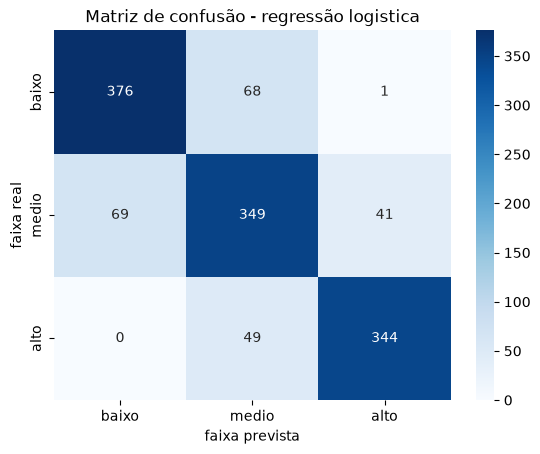

In [8]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X_conhecido, y_faixa, test_size=0.2, random_state=42, stratify=y_faixa)  # stratify mantem a proporção das faixas em treino e teste

modelo_log = Pipeline([
    ('escala', StandardScaler()),  # as colunas tem escalas bem diferentes (density ~0.99, total sulfur dioxide ~100), a logistica precisa de tudo na mesma escala
    ('logistica', LogisticRegression(max_iter=2000)),
])
modelo_log.fit(X_treino, y_treino)

faixa_prevista = modelo_log.predict(X_teste)
proba_prevista = modelo_log.predict_proba(X_teste)

print("METRICAS DE CLASSIFICAÇÃO (teste, 20% dos vinhos com alcohol conhecido)")
print(f"acuracia : {accuracy_score(y_teste, faixa_prevista):.3f}")
print(f"precisao : {precision_score(y_teste, faixa_prevista, average='macro'):.3f}")
print(f"recall   : {recall_score(y_teste, faixa_prevista, average='macro'):.3f}")
print(f"f1-score : {f1_score(y_teste, faixa_prevista, average='macro'):.3f}")
print(f"roc auc  : {roc_auc_score(y_teste, proba_prevista, multi_class='ovr'):.3f}")  # ovr pq são 3 classes: calcula uma curva ROC por faixa e tira a media
print("\nrelatorio por faixa:")
print(classification_report(y_teste, faixa_prevista))

matriz = confusion_matrix(y_teste, faixa_prevista, labels=nomes_faixas)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_faixas, yticklabels=nomes_faixas)
plt.xlabel('faixa prevista')
plt.ylabel('faixa real')
plt.title('Matriz de confusão - regressão logistica')
plt.show()

In [9]:
# aplica o modelo nas 15 linhas sem alcohol e compara com o gabarito do wines.csv
faixa_faltante = modelo_log.predict(X_faltante)
proba_faltante = modelo_log.predict_proba(X_faltante)
alcohol_logistica = pd.Series(mediana_por_faixa.loc[faixa_faltante].values, index=X_faltante.index)  # preenchimento: mediana da faixa prevista

faixa_real = pd.cut(alcohol_real, bins=limites, labels=nomes_faixas, include_lowest=True)  # faixa em que o valor verdadeiro cai, com os mesmos cortes

comparacao_log = pd.DataFrame({
    'alcohol_real': alcohol_real,
    'faixa_real': faixa_real,
    'faixa_prevista': faixa_faltante,
    'alcohol_preenchido': alcohol_logistica,
})
comparacao_log['erro'] = (comparacao_log['alcohol_preenchido'] - comparacao_log['alcohol_real']).round(2)
display(comparacao_log)

print("VALIDAÇÃO COM WINES.CSV (15 linhas)")
print(f"acuracia : {accuracy_score(faixa_real, faixa_faltante):.3f}")
print(f"precisao : {precision_score(faixa_real, faixa_faltante, average='macro', zero_division=0):.3f}")
print(f"recall   : {recall_score(faixa_real, faixa_faltante, average='macro', zero_division=0):.3f}")
print(f"f1-score : {f1_score(faixa_real, faixa_faltante, average='macro', zero_division=0):.3f}")
print(f"roc auc  : {roc_auc_score(faixa_real, proba_faltante, multi_class='ovr'):.3f}")
print("\nmatriz de confusão (linha = real, coluna = prevista, ordem baixo/medio/alto):")
print(confusion_matrix(faixa_real, faixa_faltante, labels=nomes_faixas))

# mesmo com a faixa certa, o valor preenchido é a mediana da faixa. em graus de alcool o erro fica assim:
print(f"\nMAE do preenchimento : {mean_absolute_error(alcohol_real, alcohol_logistica):.3f}")
print(f"RMSE do preenchimento: {np.sqrt(mean_squared_error(alcohol_real, alcohol_logistica)):.3f}")

,alcohol_real,faixa_real,faixa_prevista,alcohol_preenchido,erro
865,9.9,medio,medio,10.4,0.5
1151,11.7,alto,alto,11.9,0.2
1382,9.0,baixo,baixo,9.3,0.3
1604,9.6,baixo,baixo,9.3,-0.3
1747,13.1,alto,alto,11.9,-1.2
2333,8.8,baixo,baixo,9.3,0.5
2614,10.3,medio,baixo,9.3,-1.0
2703,10.4,medio,medio,10.4,0.0
2742,12.2,alto,alto,11.9,-0.3
3197,12.2,alto,medio,10.4,-1.8


VALIDAÇÃO COM WINES.CSV (15 linhas)
acuracia : 0.867
precisao : 0.878
recall   : 0.867
f1-score : 0.866
roc auc  : 0.980

matriz de confusão (linha = real, coluna = prevista, ordem baixo/medio/alto):
[[5 0 0]
 [1 4 0]
 [0 1 4]]

MAE do preenchimento : 0.513
RMSE do preenchimento: 0.686


In [10]:
# 5) regressão polinomial

# aqui alcohol volta a ser previsto como numero. os graus 1, 2 e 3 são comparados com validação cruzada no treino, antes de olhar o teste
X_treino_r, X_teste_r, y_treino_r, y_teste_r = train_test_split(X_conhecido, y_conhecido, test_size=0.2, random_state=42)

def monta_polinomial(grau):
    return Pipeline([
        ('escala', StandardScaler()),
        ('poli', PolynomialFeatures(degree=grau, include_bias=False)),  # cria as colunas ao quadrado, ao cubo e as multiplicações entre colunas
        ('linear', LinearRegression()),
    ])

r2_por_grau = {}
for grau in [1, 2, 3]:
    r2_cv = cross_val_score(monta_polinomial(grau), X_treino_r, y_treino_r, cv=5, scoring='r2')
    r2_por_grau[grau] = r2_cv.mean()
    qtd_termos = monta_polinomial(grau).fit(X_treino_r, y_treino_r)['poli'].n_output_features_
    print(f"grau {grau}: {qtd_termos:>3} termos | R2 medio na validação cruzada = {r2_cv.mean():.3f} (desvio {r2_cv.std():.3f})")

melhor_grau = max(r2_por_grau, key=r2_por_grau.get)
print("\nmelhor grau:", melhor_grau)  # grau 3 cria centenas de colunas a partir de 12, decora o treino e o R2 despenca fora dele

grau 1:  12 termos | R2 medio na validação cruzada = 0.803 (desvio 0.069)
grau 2:  90 termos | R2 medio na validação cruzada = 0.867 (desvio 0.018)
grau 3: 454 termos | R2 medio na validação cruzada = 0.135 (desvio 1.362)

melhor grau: 2


METRICAS DE REGRESSÃO (teste, grau 2)
MAE         0.312
MSE         0.207
RMSE        0.455
MAPE (%)    2.991
R2          0.854
dtype: float64

VALIDAÇÃO COM WINES.CSV (15 linhas)
MAE         0.399
MSE         0.302
RMSE        0.549
MAPE (%)    3.545
R2          0.828
dtype: float64


,alcohol_real,mediana,logistica,polinomial
865,9.9,10.3,10.4,10.12
1151,11.7,10.3,11.9,12.14
1382,9.0,10.3,9.3,8.81
1604,9.6,10.3,9.3,9.67
1747,13.1,10.3,11.9,11.97
2333,8.8,10.3,9.3,8.98
2614,10.3,10.3,9.3,9.60
2703,10.4,10.3,10.4,10.29
2742,12.2,10.3,11.9,11.42
3197,12.2,10.3,10.4,10.93


erro de cada tecnica nas 15 linhas, contra o wines.csv:


,MAE,MSE,RMSE,MAPE (%),R2
mediana,1.093,1.824,1.351,10.060,-0.041
logistica,0.513,0.470,0.686,4.743,0.732
polinomial,0.399,0.302,0.550,3.545,0.828


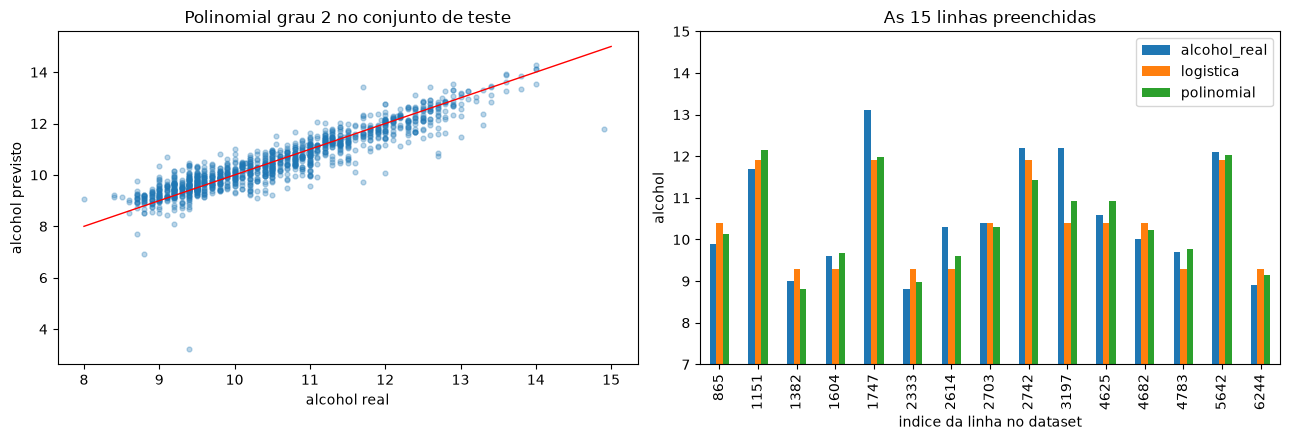


pior erro no teste: linha 4402, real 9.4, previsto 3.22


,color,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,quality
4402,1,9.2,0.52,1.0,3.4,0.61,32.0,69.0,0.9996,2.74,2.0,4


faltantes em alcohol depois do preenchimento: 0


In [11]:
modelo_poli = monta_polinomial(melhor_grau).fit(X_treino_r, y_treino_r)
alcohol_previsto_teste = modelo_poli.predict(X_teste_r)

def metricas_regressao(y_real, y_previsto):
    return pd.Series({
        'MAE': mean_absolute_error(y_real, y_previsto),
        'MSE': mean_squared_error(y_real, y_previsto),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_previsto)),
        'MAPE (%)': mean_absolute_percentage_error(y_real, y_previsto) * 100,
        'R2': r2_score(y_real, y_previsto),
    })

print(f"METRICAS DE REGRESSÃO (teste, grau {melhor_grau})")
print(metricas_regressao(y_teste_r, alcohol_previsto_teste).round(3))

alcohol_polinomial = pd.Series(modelo_poli.predict(X_faltante), index=X_faltante.index)
print("\nVALIDAÇÃO COM WINES.CSV (15 linhas)")
print(metricas_regressao(alcohol_real, alcohol_polinomial).round(3))

# as tres tecnicas lado a lado: mediana (usada nas outras colunas na questão 1), logistica e polinomial
comparacao_final = pd.DataFrame({
    'alcohol_real': alcohol_real,
    'mediana': y_conhecido.median(),
    'logistica': alcohol_logistica,
    'polinomial': alcohol_polinomial.round(2),
})
display(comparacao_final)

resumo = pd.DataFrame({
    tecnica: metricas_regressao(alcohol_real, comparacao_final[tecnica])
    for tecnica in ['mediana', 'logistica', 'polinomial']
}).T.round(3)
print("erro de cada tecnica nas 15 linhas, contra o wines.csv:")
display(resumo)

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.5))
eixos[0].scatter(y_teste_r, alcohol_previsto_teste, alpha=0.3, s=12)
eixos[0].plot([8, 15], [8, 15], color='red', linewidth=1)  # linha onde previsto = real
eixos[0].set_xlabel('alcohol real')
eixos[0].set_ylabel('alcohol previsto')
eixos[0].set_title(f'Polinomial grau {melhor_grau} no conjunto de teste')
comparacao_final[['alcohol_real', 'logistica', 'polinomial']].plot(kind='bar', ax=eixos[1])
eixos[1].set_ylim(7, 15)
eixos[1].set_xlabel('indice da linha no dataset')
eixos[1].set_ylabel('alcohol')
eixos[1].set_title('As 15 linhas preenchidas')
plt.tight_layout()
plt.show()

# o ponto isolado do grafico é o pior erro do teste: um tinto com chlorides 0.61 e sulphates 2.0, os maiores do dataset inteiro.
# o polinomio eleva esses valores ao quadrado e a previsão cai pra 3 graus. vinho muito fora do padrão do treino, o modelo erra feio
previsto_teste = pd.Series(alcohol_previsto_teste, index=y_teste_r.index)
pior = (previsto_teste - y_teste_r).abs().idxmax()
print(f"\npior erro no teste: linha {pior}, real {y_teste_r[pior]}, previsto {previsto_teste[pior]:.2f}")
display(X_teste_r.loc[[pior]])

# preenchimento final com a polinomial, que teve o menor erro
df_wines_preprocessing.loc[linhas_sem_alcohol, 'alcohol'] = alcohol_polinomial.round(2)
print("faltantes em alcohol depois do preenchimento:", df_wines_preprocessing['alcohol'].isna().sum())

#### E-mail (questão 5)

Para: Sir. Donald Shelby

Assunto: Coluna Alcohol: por que a regressão logística não foi usada no preenchimento

Sr. Shelby,

O preenchimento dos 15 valores que faltavam na coluna Alcohol está concluído. A regressão logística solicitada foi implementada e avaliada, mas a versão final da planilha usa uma regressão polinomial.

A regressão logística é um algoritmo de classificação: ela devolve a probabilidade de uma amostra pertencer a uma categoria. O teor alcoólico é uma medida contínua, vai de 8,0 a 14,9 graus e tem mais de cem valores diferentes na planilha. Para aplicar a logística foi preciso transformar o teor alcoólico em categorias. O Alcohol foi cortado em três faixas de tamanho parecido (baixo, até 9,7; médio, até 11,0; alto, acima disso) e o modelo foi treinado para prever a faixa. Ele acerta a faixa em 82% dos vinhos de teste e a área sob a curva ROC ficou em 0,945, ou seja, como classificador está bom. O problema aparece na hora de preencher: como o modelo só sabe a faixa, o valor que entra é a mediana dela (9,3, 10,4 ou 11,9). Um vinho de 13,1 graus, por exemplo, recebeu 11,9 mesmo com a faixa certa. Nas 15 linhas que faltavam o erro médio foi de 0,51 grau. Transformar número em categoria joga informação fora, e ela não volta na hora de preencher.

Na regressão polinomial o alvo continua sendo o número. Os graus 1, 2 e 3 foram comparados por validação cruzada e o grau 2 foi o melhor. O grau 3 cria 454 colunas a partir de 12, decora os dados de treino e erra muito fora deles. No conjunto de teste o modelo de grau 2 explicou 85% da variação do teor alcoólico (R² de 0,854) com erro médio de 0,31 grau. Nas mesmas 15 linhas o erro médio caiu para 0,40 grau, contra 0,51 da logística e 1,09 se a mediana da coluna fosse repetida, como foi feito nas outras colunas. A variável que mais ajuda o modelo é a densidade: álcool é menos denso que água, então vinho com mais álcool tem densidade menor, e essa relação aparece forte nos dados (correlação de -0,69).

A recomendação é manter a regressão polinomial de grau 2 para preencher os valores faltantes de Alcohol. A planilha tratada já está com esses valores.

Carlos

### Análise Exploratória
**Utilize o dataset 'wines.csv'**

A enóloga Marilyn Monroe, direta do Sir. Pounce, tomou conhecimento de suas habilidades exploratórias e requereu gráficos "chiques, reuscados, enfeitados e nada triviais" que mostrassem, de forma interativa todos os dados e seus respectivos insights. A principal exigência é de que as paletas de cores sejam harmônicas, de modo que possam ser utilizadas em apresentações. Para isso, sugeriu a documentação a seguir:
[Colors Palettes](https://plotly.com/python/builtin-colorscales/)

1- Utilize um countplot para averiguar a quantidade de vinhos por cada avaliação de qualidade. 
Separare entre vinhos tintos e brancos, fazendo um gráfico para cada tipo.

2- Utilize um jointplot para descrever a relação entre álcool e açucar. Utilizar o tipo 'KDE'.

3- Utilize um boxplot para verificar se existe algum vinho que seja considerado um outlier. Utilize **x = 'quality'** e **y='residual sugar'**. Identificando os outliers, crie um novo dataframe, utilize um barplot para contabilizar a quantidade de vinhos tintos
e brancos por qualidade de modo que as barras estejam sobrepostas em relação ao tipo de vinho.   

4- Faça um gráfico de correlação e encontre quais são as 'features' que contém correlações
positivas e negativas fortes  entre si. Em seguida, utilize o scatterplot, colocando no eixo "x" e "y"
cada variável correlata e descreva por escrito o motivo da distribuição e o sentido vetorial estarem apresentados
das respectivas formas.

**ps**: Para este problema, entenda como correlações fortes valores menores que -0.4 e maiores que 0.4.

In [13]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np 

df_wines = pd.read_csv('../data/wines.csv')

paleta_tipo = {'red': '#7B241C', 'white': '#D4AC0D'}  

**Countplot de qualidade, separado por tipo de vinho**

In [15]:
df_tinto = df_wines[df_wines['color'] == 'red']
df_branco = df_wines[df_wines['color'] == 'white']

fig_tinto = px.histogram(
    df_tinto, x='quality', color='quality',
    color_discrete_sequence=px.colors.sequential.Sunsetdark,
    title='Vinhos Tintos - Contagem por Qualidade', text_auto=True
)
fig_tinto.update_layout(template='plotly_white', showlegend=False, xaxis=dict(dtick=1), title_x=0.5)
fig_tinto.show()

fig_branco = px.histogram(
    df_branco, x='quality', color='quality',
    color_discrete_sequence=px.colors.sequential.YlOrBr,
    title='Vinhos Brancos - Contagem por Qualidade', text_auto=True
)
fig_branco.update_layout(template='plotly_white', showlegend=False, xaxis=dict(dtick=1), title_x=0.5)
fig_branco.show()

a distribuição de qualidade é parecida entre tintos e brancos,
concentrada nas notas 5, 6 e 7. Poucos vinhos recebem notas extremas.

**Jointplot (KDE) - Álcool x Açúcar Residual**

In [16]:
fig = make_subplots(
    rows=2, cols=2,
    column_widths=[0.8, 0.2], row_heights=[0.2, 0.8],
    horizontal_spacing=0.02, vertical_spacing=0.02
)

fig.add_trace(
    go.Histogram2dContour(
        x=df_wines['alcohol'], y=df_wines['residual sugar'],
        colorscale='Tealrose', showscale=False,
        contours=dict(coloring='heatmap')
    ), row=2, col=1
)
fig.add_trace(
    go.Histogram(x=df_wines['alcohol'], marker_color='#7b241C', nbinsx=40, showlegend=False),
    row=1,col=1
)
fig.add_trace(
    go.Histogram(y=df_wines['residual sugar'], marker_color='#D4AC0D', nbinsy=40, showlegend=False),
    row=2, col=2
)

fig.update_layout(title_text='Densidade KDE - Álcool x Açúcar Residual', title_x=0.5,
                  template='plotly_white', height=600, width=700)

fig.update_xaxes(title_text='Álcool(%)', row=2, col=1)
fig.update_yaxes(title_text='Açúcar Residual(g/L)', row=2, col=1)
fig.show()

Maior densidade em açúcar residual baixo (< 5 g/L) e álcool entre 9% e 12,5%.
Existe uma cauda de vinhos mais doces (açúcar residual > 20 g/L), tipicamente com teor alcoólico um pouco mais baixo.

**Boxplot de outliers (quality x residual sugar) e barplot sobreposto**

In [17]:
fig = px.box(
    df_wines, x='quality', y='residual sugar', color='quality',
    color_discrete_sequence= px.colors.sequential.Sunsetdark,
    points='outliers', title='Boxplot - Açúcar Residual por Qualidade'
)

fig.update_layout(template='plotly_white', showlegend=False, title_x=0.5)
fig.show()

In [18]:
q1 = df_wines.groupby('quality')['residual sugar'].transform(lambda s: s.quantile(0.25))
q3 = df_wines.groupby('quality')['residual sugar'].transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

eh_outlier = (df_wines['residual sugar'] < limite_inferior) | (df_wines['residual sugar'] > limite_superior)
df_outliers = df_wines[eh_outlier].copy() #novo dataframe com os outliers

print(f'Total de vinhos outliers: {len(df_outliers)}')
df_outliers[['color', 'quality', 'residual sugar']].sort_values('residual sugar', ascending=False).head(10)

Total de vinhos outliers: 147


,color,quality,residual sugar
4391,white,6,65.80
5275,white,6,31.60
5708,white,6,31.60
1982,white,6,26.05
3593,white,6,26.05
1871,white,5,23.50
4165,white,5,22.60
1366,white,5,22.00
3589,white,5,22.00
2152,white,6,20.80


In [19]:
contagem = df_outliers.groupby(['quality', 'color']).size().reset_index(name='contagem')

fig = px.bar(
    contagem, x='quality', y='contagem', color='color',
    color_discrete_map=paleta_tipo, barmode='overlay', opacity=0.75,
    title='Vinhos Outliers(Açúcar Residual) por Qualidade - Tinto x Branco'
)

fig.update_layout(template='plotly_white', title_x=0.5, xaxis=dict(dtick=1))
fig.show()

A maioria dos outliers de açúcar residual é de vinhos brancos, coerente
com a existência de brancos bem mais doces no dataset (raro entre os tintos).

**Correlação entre features**

In [20]:
corr = df_wines.select_dtypes('number').corr()

fg = px.imshow(
    corr, text_auto='.2f', color_continuous_scale='Tealrose', zmin=1, zmax=1,
    title='Mapa de Correlação - Variáveis Físico-Químicas'

)
fig.update_layout(template='plotly_white', title_x=0.5, height=600)
fig.show()



In [21]:
mascara = np.triu(np.ones(corr.shape),k=1).astype(bool)
pares = corr.where(mascara).stack().reset_index()
pares.columns = ['var1', 'var2', 'corr']
fortes = pares[(pares['corr'] > 0.4) | (pares['corr'] < -0.4)].sort_values('corr', ascending=False)
fortes

,var1,var2,corr
66,free sulfur dioxide,total sulfur dioxide,0.720934
43,residual sugar,density,0.552517
42,residual sugar,total sulfur dioxide,0.495482
7,fixed acidity,density,0.458910
131,alcohol,quality,0.444319
41,residual sugar,free sulfur dioxide,0.402871
18,volatile acidity,total sulfur dioxide,-0.414476
94,density,alcohol,-0.686745


**Pares com correlação forte encontrados:**
- "free sulfur dioxide" x "total sulfur dioxide": r = 0.72 (positiva)
- "residual sugar" x "density": r = 0.55 (positiva)
- "residual sugar" x "total sulfur dioxide": r = 0.50 (positiva)
- "fixed acidity" x "density": r = 0.46 (positiva)
- "alcohol" x "quality": r = 0.44 (positiva)
- "residual sugar" x "free sulfur dioxide": r = 0.40 (positiva)
- "volatile acidity' x "total sulfur dioxide": r = -0.41 (negativa)
- "density" x "alcohol": r = -0.69 (negativa)

**scatterplots para a correlação positiva e negativa mais fortes.**

In [31]:
fig = px.scatter(
    df_wines, x='free sulfur dioxide', y='total sulfur dioxide', color='color',
    color_discrete_map=paleta_tipo, opacity=0.5, trendline='ols',
    title='SO2 Livre x SO2 Total (r = 0.72)'
)
fig.update_layout(template='plotly_white', title_x=0.5)
fig.show()

Por que a nuvem de pontos sobe (correlação positiva)?
O SO2 total é, a soma do SO2 livre com o SO2 combinado a outras moléculas de vinho. Como o SO2 livre é uma parte do SO2 total, é esperado que, quanto mais SO2 livre um vinho tiver, maior tende a ser SO2 total, por isso a relação é proporcional.

In [32]:
fig = px.scatter(
    df_wines, x='density', y='alcohol', color='color',
    color_discrete_map=paleta_tipo, opacity=0.5, trendline='ols',
    title='Densidade x Álcool (r = -0.69)'
)
fig.update_layout(template='plotly_white', title_x=0.5)
fig.show()

Por que a nuvem de pontos desce (correlação negativa)?
Durante a fermentação, o açúcar(com mais densidade que a água) é convertido em álcool(menos densidade).Vinhos com maior teor alcoólico tiveram uma fermentação mais completa,restando menos residuos de açúcar, o que reduz a densidade final do vinho. Por isso a dispersão demonstra uma relação inversa proporcional.

# Modelos Supervisionados 

### Classificação
**Utilize o dataset 'wine_classification.csv'.**

Após alguns meses, o filho do Sir. Donald Shelby, Chuck Norris Shelby, mais conhecido como "El Chavo del Ocho", em decorrência de seu "notório" saber e comportamento extrovertido, ~para ser eufemista~, foi promovido a "*head*" de Machine Learning, vulgo seu chefe. 

Com suas inusitadas e inovadoras ideias, pediu que você criasse três modelos de árvores, um do tipo "random" e dois do tipo "boost", pois havia descoberto que a otimização pelo gradiente descendente era considerada como "*The American Dream*". Não obstante, gostaria de analisar o gráfico de importância das features.

Ademais, requereu que utilizasse o algoritmo SVM, pelo fato do "kernel trick" performar bem em problemas de altas dimensionalidades. Um KNN "cairia bem também, vamos utilizar por mero desencargo de consciência", disse.  

Em seu discurso inflamado, se pronunciava: "Precisamos realizar tais façanhas nunca vistas na história da Inteligência Artificial, desde que as redes neurais foram introduzidas por Walter Pitts e Warren McCulloch em 1943. Vamos predizer tudo que quisermos, independentemente da uva utilizada na produção. Eu transformarei nossa vinícola na melhor do mundo, pois sou detentor do saber". Tudo dito numa reunião contendo 12 pessoas, trabalhadores braçais inclusos. Tal discurso invejou os oráculos delfos e os lembraram de Sócrates em seu julgamento, antes de morrer. 

Após tamanhas proclamações, apontou em sua direção e disse: **"VOCÊ, É..., VOCÊ MESMO**, irás fazer todo o processo por conta própria, e eu direi se o que fazes está correto! Não utilizarás Auto-ML, pois eu, ~professor~, quero ter certeza de que entende seu labor e suas nuâncias". 

Você, cansado e entediado de tantas lorotas, se retirou da reunião com "dores" na região abdominal, porém ainda recebeu um e-mail lhe instruindo a comparar os resultados de todas as implementações, escolher o melhor modelo e utilizar métodos de otimização de hiperparâmetro.  

Em suma?

1- Crie um pipeline que contenha ao menos 05 tipos diferentes de algoritmos de classificação. 

2- Crie um DataFrame que contenha todos os resultados de todos os algoritmos utilizados, inclusive a métrica ROC AUC.

3- Comparar os resultados, escolher o melhor modelo e otimizar os parâmetros. Ao fim, faça um gráfico da ROC AUC.


In [23]:
# VERIFICAR DF
df_class = pd.read_csv('../data/wine_classification.csv')
df_class.head()

,level_0,index,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,85915,25915,8.245448,1.069629,0.308244,8.553958,0.544424,47.996220,102.963745,0.991074,3.752924,1.626359,11.919210,3.0
1,160937,40937,11.116896,1.498028,0.295353,4.511794,0.063113,8.254940,179.753950,1.002291,2.900818,1.750531,13.325149,4.0
2,61508,1508,8.450324,0.948507,0.258336,7.668017,0.288771,64.182620,258.045140,0.993694,2.870722,1.633690,12.220562,8.0
3,86589,26589,14.872544,1.060595,0.967109,4.383509,0.206029,45.940273,268.662720,0.997456,3.268399,0.374033,11.494769,7.0
4,12287,12287,13.555627,1.212422,0.724181,9.436988,0.396179,34.868042,162.530580,0.994683,3.530383,1.301167,12.176147,8.0


In [26]:
df_class.info()

<class 'pandas.DataFrame'>
RangeIndex: 13701 entries, 0 to 13700
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   level_0               13701 non-null  int64  
 1   index                 13701 non-null  int64  
 2   fixed acidity         13701 non-null  float64
 3   volatile acidity      13701 non-null  float64
 4   citric acid           13701 non-null  float64
 5   residual sugar        13701 non-null  float64
 6   chlorides             13701 non-null  float64
 7   free sulfur dioxide   13701 non-null  float64
 8   total sulfur dioxide  13701 non-null  float64
 9   density               13701 non-null  float64
 10  pH                    13701 non-null  float64
 11  sulphates             13701 non-null  float64
 12  alcohol               13701 non-null  float64
 13  quality               13701 non-null  float64
dtypes: float64(12), int64(2)
memory usage: 1.5 MB


In [29]:
df_class.nunique()

level_0                 7061
index                   6798
fixed acidity           7059
volatile acidity        7060
citric acid             7058
residual sugar          7060
chlorides               7061
free sulfur dioxide     7058
total sulfur dioxide    7057
density                 6835
pH                      7054
sulphates               7059
alcohol                 7055
quality                    6
dtype: int64

In [34]:
df_class['quality'].value_counts()

quality
3.0    4719
5.0    2487
4.0    2369
6.0    1663
8.0    1271
7.0    1192
Name: count, dtype: int64

In [62]:
# ESCALAR / ENCODAR
# Para tratar o nosso alvo vamos primeiramente com o LabelEncoder trazer a escala de 3-8 para 0-5, isso não seria necessario para boa parte de nossos modelos porém o XGBoost exige classes inteiras consecutivas começando de 0

"Miscellaneous - By default, XGBoost assumes input category codes are integers starting from 0 till the number of categories [0,𝑛_𝑐⁢𝑎⁢𝑡⁢𝑒⁢𝑔⁡𝑜⁢𝑟⁢𝑖⁢𝑒⁢𝑠).[...]"
- fonte: https://xgboost.readthedocs.io/en/stable/tutorials/categorical.html

In [54]:
from sklearn.preprocessing import LabelEncoder

encoder_y = LabelEncoder()
y = encoder_y.fit_transform(df_class['quality'])

X = df_class.drop(columns=['quality', 'level_0', 'index']) #Dropei também as colunas contendo indexes

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12, stratify=y) #Utilização do stratify para manter a proporção no treino e teste da classe y tentando evitar problemas de vies

In [40]:
# Para trabalhar melhor com os modelos de SVM e KNN que são sensiveis a escala vamos adotar o StandardScaler para trazer os dados para uma escala única. Para os resultados dos demais modelos não temos mudanças significativas estando ou não escalados.

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform='pandas')
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)

In [60]:
X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
10679,-0.575024,0.928231,-1.677094,1.939105,0.720139,1.123207,-1.438405,-1.595620,0.944158,1.546986,1.001183
12670,2.416256,-1.660665,0.818153,-0.177470,1.079614,1.953494,1.038982,-1.593205,1.977473,-0.407080,-0.530196
11974,1.786976,1.197414,0.553605,1.126238,-1.993253,-1.781506,-1.703379,2.046281,-0.560774,0.118353,0.645196
5920,-0.384278,1.644680,1.446073,0.310493,-1.452160,-1.810879,-1.167404,1.871447,0.142699,0.631823,0.332466
5710,-0.147816,1.526291,1.382065,0.738961,-1.396581,-1.840872,-1.353140,1.957132,-0.160332,0.494304,0.629048


In [67]:
# CRIAR PIPELINE - KNN, RANDOM FOREST, CATBOOST, ADABOST, XGBOOST e SVM

from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

models = [('KNN', KNeighborsClassifier()), # Por padrão vai utilizar o kernel rbf
          ('RandomForest', RandomForestClassifier(n_estimators=100,random_state=12, n_jobs=-1)),
          ('CatBoost', CatBoostClassifier(n_estimators=100,loss_function='MultiClass', verbose=0, random_state=12)), #Define a função de perda que o modelo tenta minimizar durante o treinamento, adequada para prever uma entre várias classes
          ('AdaBoost', AdaBoostClassifier(n_estimators=100,random_state=12)),
          ('XGBoost', XGBClassifier(n_estimators=100,eval_metric='mlogloss', random_state=12)),
          ('SVM', SVC())]

# Verbose = Desativa as mensagens de progresso do treinamento, deixando a saída do notebook mais limpa. Não muda o aprendizado do modelo.
# Logloss é usada para classificação binária, enquanto MultiClass e mlogloss são adequadas para várias classe

-------------------------KNN--------------------------

[[834  34  46  14  12   4]
 [ 65 357  10  24  11   7]
 [ 83  29 305  38  16  27]
 [ 38  22  30 218  15  10]
 [ 59  27  12  25 106   9]
 [ 41  22  41  16  14 120]]
              precision    recall  f1-score   support

           0       0.74      0.88      0.81       944
           1       0.73      0.75      0.74       474
           2       0.69      0.61      0.65       498
           3       0.65      0.65      0.65       333
           4       0.61      0.45      0.51       238
           5       0.68      0.47      0.56       254

    accuracy                           0.71      2741
   macro avg       0.68      0.64      0.65      2741
weighted avg       0.70      0.71      0.70      2741

AUC macro: 0.931

-------------------------RandomForest--------------------------

[[904  13  16   6   3   2]
 [ 21 432   9  11   1   0]
 [ 24   4 445  11   4  10]
 [ 11   5  13 296   4   4]
 [ 19   4   1   8 203   3]
 [  6   5  14   7   

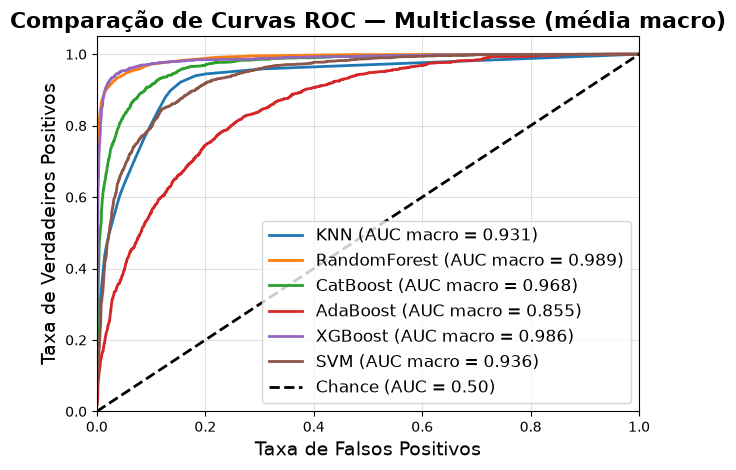

CPU times: total: 1min
Wall time: 28.9 s


In [86]:
%%time

# PREDICT e o RELATÓRIO DAS MÉTRICAS
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
# ROC e AUC DOS 5 MODELOS
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

predictions = {}

for name, model in models:
    model_steps = Pipeline(steps=[('models', model)])
    model_steps.fit(X_train_escalado, y_train)
    predictions = model_steps.predict(X_test_escalado)
    print(f'-------------------------{name}--------------------------\n')
    print(confusion_matrix(y_test, predictions))
    print(classification_report(y_test, predictions))

    # Obtenha as probabilidades de todas as classes
    if hasattr(model_steps, "predict_proba"):
        y_pred_proba = model_steps.predict_proba(X_test_escalado)
    else:  # SVM usa decision_function com saída por classe (padrão)
        y_pred_proba = model_steps.decision_function(X_test_escalado)

    # Uma coluna para cada classe, seguindo a ordem do modelo
    y_test_bin = label_binarize(y_test, classes=model_steps.classes_)

    # Calcule a curva ROC e a AUC de cada classe contra as demais
    fpr_classes = []
    tpr_classes = []
    auc_classes = []

    for i in range(len(model_steps.classes_)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        fpr_classes.append(fpr)
        tpr_classes.append(tpr)
        auc_classes.append(auc(fpr, tpr))

    # Calcule a curva média e a AUC macro
    fpr = np.unique(np.concatenate(fpr_classes))
    tpr = np.mean([
        np.interp(fpr, fpr_classe, tpr_classe)
        for fpr_classe, tpr_classe in zip(fpr_classes, tpr_classes)
    ], axis=0)
    roc_auc = np.mean(auc_classes)

    print(f'AUC macro: {roc_auc:.3f}\n')

    # Plote a curva
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC macro = {roc_auc:.3f})')

# Configure e exiba o gráfico
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos', fontsize=14)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=14)
plt.title('Comparação de Curvas ROC — Multiclasse (média macro)', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# ESCOLHER O MELHOR E OTIMIZAR COM HIPERPARAMETROS

Após todos seus esforços, o amado chefe lhe pediu para utilizar um algoritmo de classificação que ele ouviu falar, criado pelo matemático inglês Thomas Bayes. Cabe a você, mais uma vez aplicar o algoritmo e apresentar os resultado. Em seguida, faça uma breve explicação do principal problema desse método para solucionar problemas complexos.  

Dr. Anton Ego marcou uma data para comparecer na vinícula e degustar seus melhores rótulos. Nascido na França e o enólogo mais famoso do mundo, Anton era temido pelas suas análises minuciosas e certeiras. As críticas eram tão serveras que tão severas que 80% das vinículas eram fechadas pela falta de aceitação do mercado. Apenas =~ 19.99% sobreviviam sem danos consideráveis e somente $0.1x10^{-15}$% se tornavam uma lenda.

Chuck tomava leite da papoula para suportar tamanha disruptura emocional. Sir.Donald, tomado pela a ansiedade, estava com seus pruridos mentais em Nárnia até que sua esposa, Srta.Audrey Hepburn assumiu a liderança do projeto com a serenidade de um bebê.

Primeiramente ordenou que todos os vinhos que já vinham há algum tempo em processo de envelhecimento em barricas de carvalho fossem engarrafados e que amostras de todos fossem coletadas para análise. 

Sua maior preocupação é que somente sejam servidos os vinhos de nota oito ou nove, pois ambos são de mesmíssima qualidade, ficando a avaliação a critério da subjetividade palatal do degustador. Em **<u>hipótese nenhuma</u>** um vinho que não tenha tais notas pode ser servido.

De todas as novas garrafas, serão servidas somente três que você autorizar. O Dr. Ego só toma vinho tinto!


Sabendo que você já tinha um modelo validado para solucionar este tipo de problema, pediu que o usasse com a base **'desafio.csv''**. Ao fim, crie uma célula e copie os 3 vinhos que escolheu para registrar sua resposta. 
